In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import geobr
import mapclassify
import matplotlib.colors as mcolors

In [40]:
# visualizar todas as colunas
pd.set_option('display.max_columns', None)

In [41]:
#Carregando dataset
df = pd.read_csv('data/RECLAMEAQUI_PAODEACUCAR.csv')
df = df.rename(columns={'TEMPO': 'DATA', 'TRIMETRES': 'TRIMESTRES','CASOS': 'CASOS_POR_DIA'})
df['DATA'] = pd.to_datetime(df['DATA'], errors='coerce')
df.head()

,ID,TEMA,LOCAL,DATA,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMESTRES,CASOS_POR_DIA
0,147765939,Preço na prateleira diferente do que está no c...,Campinas - SP,2022-01-08,Pão de Açúcar<->Supermercados<->Propaganda eng...,Resolvido,Alegando erro operacional mas que se repete se...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
1,147699053,UTILIZAÇÃO INDEVIDA DOS MEUS STIX,São Paulo - SP,2022-01-08,Clubes de Compras e Vantagens<->Pão de Açúcar<...,Resolvido,Estou chocada pois acabei de ver um e-mail na ...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
2,147700991,Não recebi meu estorno,Rio de Janeiro - RJ,2022-01-08,Supermercados<->Não encontrei meu problema<->P...,Respondida,"Fiz um reclamação semana passada, devido uma c...",https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
3,147703729,Tiraram pontos stix da conta.,São Paulo - SP,2022-01-08,Clubes de Compras e Vantagens<->Pão de Açúcar<...,Respondida,Conclui minha a meta gasto mensal no programa ...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
4,147705769,[Editado pelo Reclame Aqui] pontos stix,São Paulo - SP,2022-01-08,Clubes de Compras e Vantagens<->Pão de Açúcar<...,Respondida,Pela segunda vez no mesmo mês tive meus pontos...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24


In [42]:
#Diagnostico
print("\n--- Informações do Dataset ---")
print(df.info())


--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             1000 non-null   int64         
 1   TEMA           1000 non-null   str           
 2   LOCAL          1000 non-null   str           
 3   DATA           1000 non-null   datetime64[us]
 4   CATEGORIA      1000 non-null   str           
 5   STATUS         1000 non-null   str           
 6   DESCRICAO      1000 non-null   str           
 7   URL            1000 non-null   str           
 8   ANO            1000 non-null   int64         
 9   MES            1000 non-null   int64         
 10  DIA            1000 non-null   int64         
 11  DIA_DO_ANO     1000 non-null   int64         
 12  SEMANA_DO_ANO  1000 non-null   int64         
 13  DIA_DA_SEMANA  1000 non-null   int64         
 14  TRIMESTRES     1000 non-null   int64         
 15  C

In [11]:
print("\n--- Dimensão do Dataset ---")
print(df.shape)


--- Dimensão do Dataset ---
(1000, 16)


In [43]:
print("\n--- Contagem de Valores Nulos ---")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if (nulls > 0).any() else "Não há valores nulos")





--- Contagem de Valores Nulos ---
Não há valores nulos


In [44]:
#Limpeza dos Dados
print(f"Registros antes da remoção de duplicatas: {len(df)}")

# drop_duplicates() remove linhas onde todos os valores são idênticos a uma linha anterior
df = df.drop_duplicates()

print(f"Registros após a remoção e duplicatas: {len(df)}\n")

Registros antes da remoção de duplicatas: 1000
Registros após a remoção e duplicatas: 1000



In [45]:
# Cleaning dos dados
# Padronização de Texto
df['TEMA'] = df['TEMA'].astype(str).str.upper().str.strip()
df['LOCAL'] = df['LOCAL'].astype(str).str.upper().str.strip()
df['STATUS'] = df['STATUS'].astype(str).str.upper().str.strip()
df['CATEGORIA'] = df['CATEGORIA'].astype(str).str.upper().str.strip()

# Separar cidade e estado
estado = df['LOCAL'].str.split(' - ').str[-1]
posicao = df.columns.get_loc('LOCAL') + 1
df.insert(posicao, 'ESTADO', estado)

# Tratamento da coluna categoria
df['CATEGORIA'] = df['CATEGORIA'].str.split('<->').apply(lambda x: [c.strip() for c in x])
#Garantindo que os dados serão inteiros
df['CASOS_POR_DIA'] = pd.to_numeric(df['CASOS_POR_DIA'], errors='coerce').fillna(0).astype(int)

In [46]:

# Nova variável temporal
df['ANO_MES'] = df['DATA'].dt.to_period('M')

In [47]:
verificacoes = {
    'ANO': df['DATA'].dt.year,
    'MES': df['DATA'].dt.month,
    'DIA': df['DATA'].dt.day,
    'DIA_DO_ANO': df['DATA'].dt.dayofyear,
    'SEMANA_DO_ANO': df['DATA'].dt.isocalendar().week,
    'TRIMESTRE': df['DATA'].dt.quarter,
    'DIA_DA_SEMANA': df['DATA'].dt.dayofweek
}

for coluna, valor_correto in verificacoes.items():
    if coluna in df.columns:
        diferencas = df[df[coluna] != valor_correto]

        if diferencas.empty:
            print(f"{coluna}: OK (sem diferenças)")
        else:
            print(f"{coluna}: {len(diferencas)} diferenças encontradas")
            print(diferencas[['DATA', coluna]].head())
            print()

ANO: OK (sem diferenças)
MES: OK (sem diferenças)
DIA: OK (sem diferenças)
DIA_DO_ANO: OK (sem diferenças)
SEMANA_DO_ANO: OK (sem diferenças)
DIA_DA_SEMANA: OK (sem diferenças)


In [48]:
df = df.drop(columns=[
    'ID',
    'URL',
    'DIA',
    'DIA_DO_ANO',
    'DIA_DA_SEMANA',
    'SEMANA_DO_ANO',
    'TRIMESTRES',
])
#REORGANIZAÇÃO DAS COLUNAS
cols_data = ['DATA','ANO','MES','ANO_MES']
outras = [c for c in df.columns if c not in cols_data]
df = df[outras+cols_data]


In [49]:
print("\n--- Dataset Final ---")
print(df.info())
print(df.shape)


--- Dataset Final ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TEMA           1000 non-null   str           
 1   LOCAL          1000 non-null   str           
 2   ESTADO         1000 non-null   object        
 3   CATEGORIA      1000 non-null   object        
 4   STATUS         1000 non-null   str           
 5   DESCRICAO      1000 non-null   str           
 6   CASOS_POR_DIA  1000 non-null   int64         
 7   DATA           1000 non-null   datetime64[us]
 8   ANO            1000 non-null   int64         
 9   MES            1000 non-null   int64         
 10  ANO_MES        1000 non-null   period[M]     
dtypes: datetime64[us](1), int64(3), object(2), period[M](1), str(4)
memory usage: 86.1+ KB
None
(1000, 11)


In [19]:
df.head()

,TEMA,LOCAL,ESTADO,CATEGORIA,STATUS,DESCRICAO,CASOS_POR_DIA,DATA,ANO,MES,ANO_MES
0,PREÇO NA PRATELEIRA DIFERENTE DO QUE ESTÁ NO C...,CAMPINAS - SP,SP,"[PÃO DE AÇÚCAR, SUPERMERCADOS, PROPAGANDA ENGA...",RESOLVIDO,Alegando erro operacional mas que se repete se...,24,2022-01-08,2022,1,2022-01
1,UTILIZAÇÃO INDEVIDA DOS MEUS STIX,SÃO PAULO - SP,SP,"[CLUBES DE COMPRAS E VANTAGENS, PÃO DE AÇÚCAR,...",RESOLVIDO,Estou chocada pois acabei de ver um e-mail na ...,24,2022-01-08,2022,1,2022-01
2,NÃO RECEBI MEU ESTORNO,RIO DE JANEIRO - RJ,RJ,"[SUPERMERCADOS, NÃO ENCONTREI MEU PROBLEMA, PÃ...",RESPONDIDA,"Fiz um reclamação semana passada, devido uma c...",24,2022-01-08,2022,1,2022-01
3,TIRARAM PONTOS STIX DA CONTA.,SÃO PAULO - SP,SP,"[CLUBES DE COMPRAS E VANTAGENS, PÃO DE AÇÚCAR,...",RESPONDIDA,Conclui minha a meta gasto mensal no programa ...,24,2022-01-08,2022,1,2022-01
4,[EDITADO PELO RECLAME AQUI] PONTOS STIX,SÃO PAULO - SP,SP,"[CLUBES DE COMPRAS E VANTAGENS, PÃO DE AÇÚCAR,...",RESPONDIDA,Pela segunda vez no mesmo mês tive meus pontos...,24,2022-01-08,2022,1,2022-01


---
# **Acompanhamento 2** 😭
---


In [50]:
#ACOMPANHAMENTO 2
# 1. Análise de Sazonalidade (Volume por Mês)
sazonalidade = df.groupby('MES')['TEMA'].count()
tabela_sazonalidade = pd.DataFrame({
    'MES': sazonalidade.index,
    'RECLAMACOES': sazonalidade.values,
})

display(tabela_sazonalidade.style.hide(axis="index"))

df['ESTADO'] = df['ESTADO'].replace('--', 'N/A')

geografica = df.groupby('ESTADO')['TEMA'].count()
tabela_geografica = pd.DataFrame({
    'ESTADO': geografica.index,
    'RECLAMACOES': geografica.values,
})

tabela_geografica = tabela_geografica.sort_values(
    by='ESTADO',
    key=lambda x: x.map(lambda v: (v == 'N/A', v))
)
print("--"*50)
display(tabela_geografica.style.hide(axis="index")) # TO-DO REVER O LOCAL NÃO CONSTA

# display(df[df['ESTADO'] == '--'])

# print("Volume de reclamações por mês:")

# print(sazonalidade)
# print(media_dia_mes)

# 2. Estatística Descritiva da variável quantitativa
# print("\nResumo Estatístico (Casos por dia):")
# qtd_casos = df['CASOS_POR_DIA'].count()
# dias_com_reclamacao = df['DATA'].nunique()
# media = qtd_casos/dias_com_reclamacao
# print(f"Media casos por dia: {media}")

MES,RECLAMACOES
1,44
2,32
3,35
4,29
5,30
6,49
7,256
8,279
9,130
10,29


----------------------------------------------------------------------------------------------------


ESTADO,RECLAMACOES
AL,3
AM,2
BA,19
CE,26
DF,42
ES,2
GO,25
MG,24
MS,5
MT,2


In [22]:
# Cruzamento Status vs Categoria (Top 10 categorias com mais reclamações)
df_explodido = df.explode('CATEGORIA')
top_categorias = df_explodido['CATEGORIA'].value_counts().nlargest(10).index
df_filtrado = df_explodido[df_explodido['CATEGORIA'].isin(top_categorias)]
cruzamento = pd.crosstab(df_filtrado['CATEGORIA'], df_filtrado['STATUS'], normalize='index') * 100
cruzamento.columns.name = 'CATEGORIA' #GAMBIARRA
cruzamento.index.name = ''#GAMBIARRA

print("Porcentagem de Status por Categoria (Top 10):")
display(cruzamento)

ValueError: cannot reindex on an axis with duplicate labels

STATUS
RESPONDIDA        36.7
RESOLVIDO         26.6
NÃO RESPONDIDA    21.0
EM RÉPLICA         8.9
NÃO RESOLVIDO      6.8
Name: proportion, dtype: float64

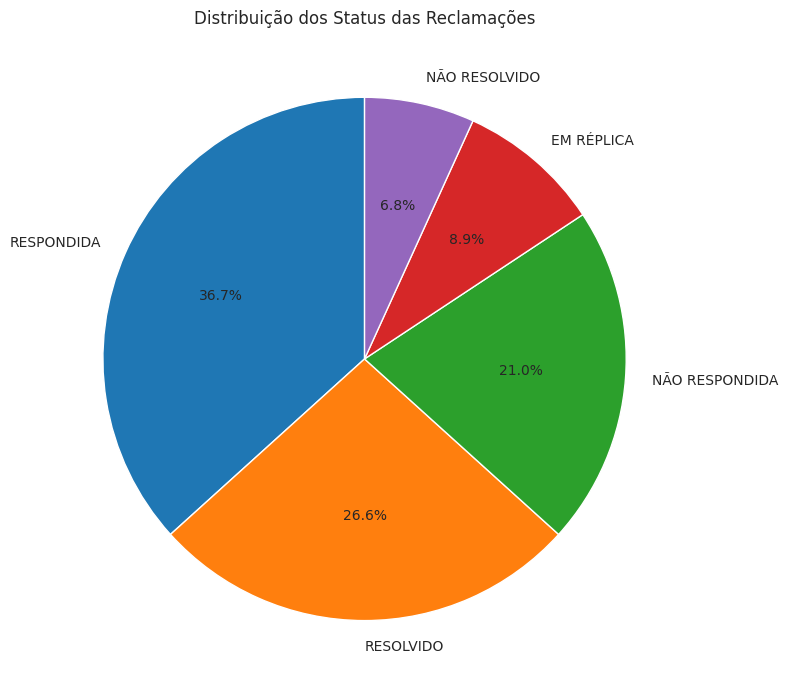

In [23]:
status_total = df['STATUS'].value_counts(normalize=True) * 100
display(status_total)

plt.figure(figsize=(8, 8))

plt.pie(
    status_total,
    labels=status_total.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribuição dos Status das Reclamações')

plt.tight_layout()
plt.show()

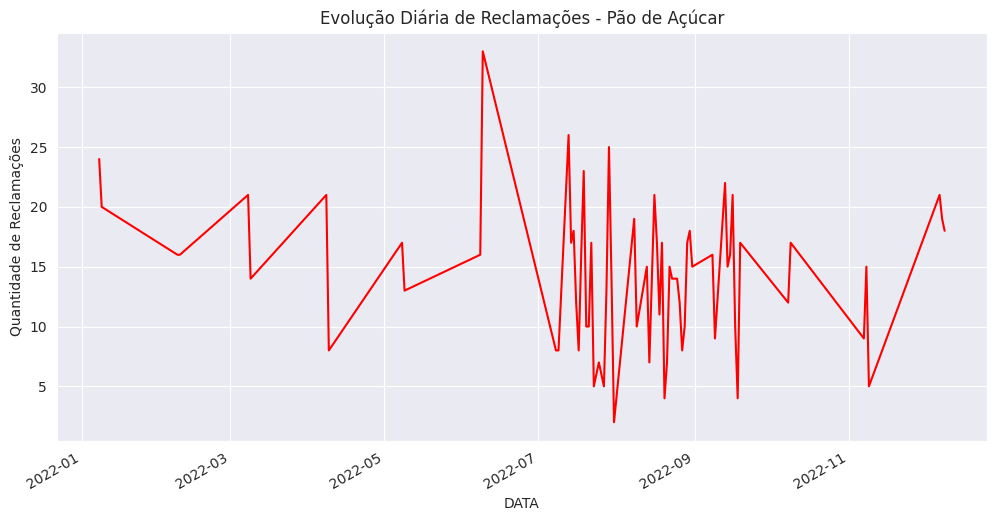

In [24]:
plt.figure(figsize=(12, 6))
df.groupby('DATA')['TEMA'].count().plot(kind='line', color='red', title='Evolução Diária de Reclamações - Pão de Açúcar')
plt.ylabel('Quantidade de Reclamações')
plt.grid(True)
plt.show()

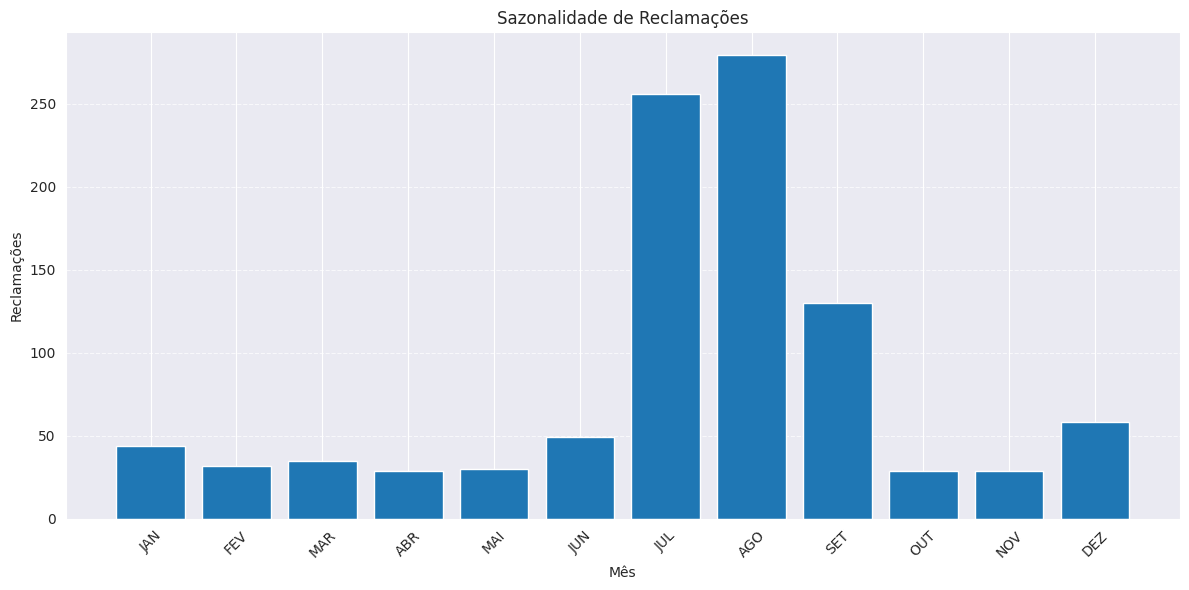

In [25]:
meses_dict = {
    1: 'JAN', 2: 'FEV', 3: 'MAR', 4: 'ABR',
    5: 'MAI', 6: 'JUN', 7: 'JUL', 8: 'AGO',
    9: 'SET', 10: 'OUT', 11: 'NOV', 12: 'DEZ'
}
tabela_sazonalidade['MES'] = tabela_sazonalidade['MES'].map(meses_dict)

x = np.arange(len(tabela_sazonalidade['MES']))  # posições numéricas

plt.figure(figsize=(12, 6))

plt.bar(x, tabela_sazonalidade['RECLAMACOES'])

plt.xlabel('Mês')
plt.ylabel('Reclamações')
plt.title('Sazonalidade de Reclamações')

# 👇 agora alinha perfeitamente
plt.xticks(x, tabela_sazonalidade['MES'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [26]:

# reclamacoes por estado em barras substituido por heatmap
# # posições numéricas
# x2 = np.arange(len(tabela_geografica))

# plt.figure(figsize=(12, 6))

# plt.bar(x2, tabela_geografica['RECLAMACOES'])

# plt.xlabel('Estado')
# plt.ylabel('Reclamações')
# plt.title('Reclamações por Estado')

# # nomes dos estados no eixo X
# plt.xticks(x2,tabela_geografica['ESTADO'], rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

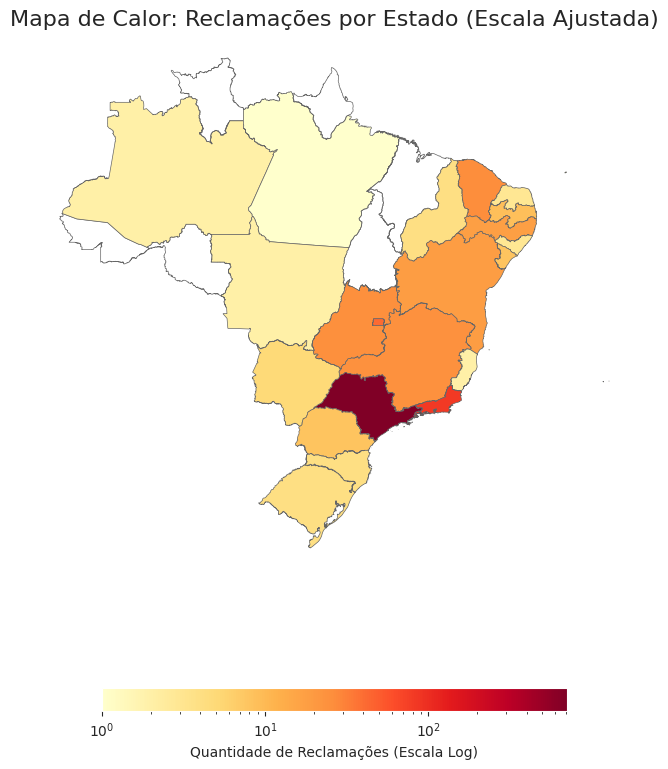

In [27]:
print("Downloading Brazil maps from geobr...")
states = geobr.read_state(year=2020)
merged_map = states.merge(
    tabela_geografica,
    left_on='abbrev_state',
    right_on='ESTADO',
    how='left'
)
merged_map['RECLAMACOES'] = merged_map['RECLAMACOES'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# # The magic happens here:
# merged_map.plot(
#     column='RECLAMACOES',
#     cmap='YlOrRd',
#     scheme='quantiles',  # Divide os dados em grupos de mesma quantidade
#     k=5,                 # Número de faixas de cor
#     legend=True,
#     ax=ax,
#     edgecolor='0.4',
#     linewidth=0.5,
#     legend_kwds={'loc': 'lower left', 'title': "Qtd. Reclamações"}
# )

# OPÇÃO B: Se não quiser instalar o mapclassify, use escala Logarítmica:
# Basta descomentar as linhas abaixo e comentar a 'merged_map.plot' acima
vmin = merged_map['RECLAMACOES'].min() if merged_map['RECLAMACOES'].min() > 0 else 1
vmax = merged_map['RECLAMACOES'].max()
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

merged_map.plot(
    column='RECLAMACOES',
    cmap='YlOrRd',
    norm=norm,
    legend=True,
    ax=ax,
    edgecolor='0.4',
    linewidth=0.5,
    legend_kwds={'label': "Quantidade de Reclamações (Escala Log)", 'orientation': "horizontal", 'shrink': 0.5}
)


# Cosmetic Polish
ax.set_title('Mapa de Calor: Reclamações por Estado (Escala Ajustada)', fontsize=16)
ax.axis('off')

plt.show()





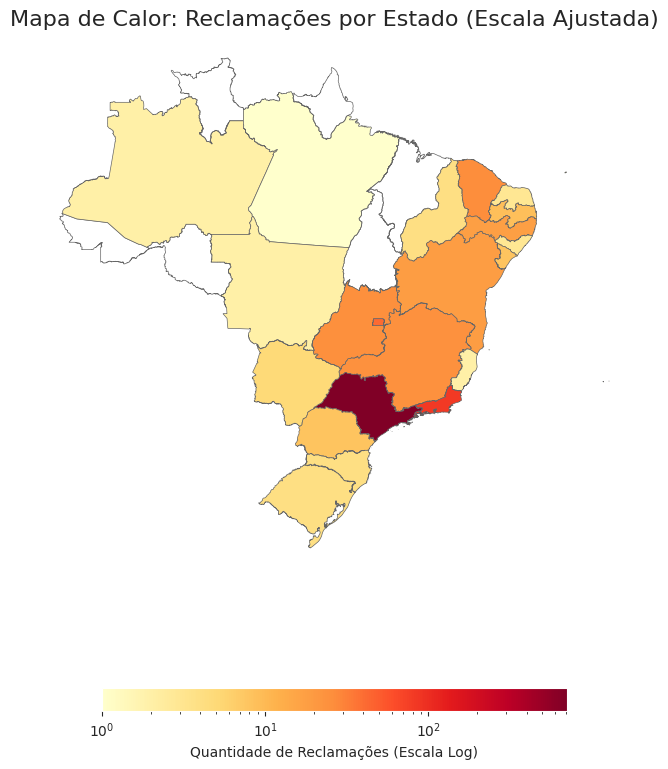

In [28]:

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# OPÇÃO B: Se não quiser instalar o mapclassify, use escala Logarítmica:
# Basta descomentar as linhas abaixo e comentar a 'merged_map.plot' acima
vmin = merged_map['RECLAMACOES'].min() if merged_map['RECLAMACOES'].min() > 0 else 1
vmax = merged_map['RECLAMACOES'].max()
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

merged_map.plot(
    column='RECLAMACOES',
    cmap='YlOrRd',
    norm=norm,
    legend=True,
    ax=ax,
    edgecolor='0.4',
    linewidth=0.5,
    legend_kwds={'label': "Quantidade de Reclamações (Escala Log)", 'orientation': "horizontal", 'shrink': 0.5}
)

ax.set_title('Mapa de Calor: Reclamações por Estado (Escala Ajustada)', fontsize=16)
ax.axis('off')

plt.show()

In [52]:
df.to_csv("df_final.csv", index=False, encoding="utf-8-sig")